<a href="https://colab.research.google.com/github/andressonsino/optimizacion-algoritmos-geneticos/blob/main/algoritmos_geneticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 31.7 MB/s eta 0:00:00


## Resolución



1. **Modelado de Datos**


In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)


2.  **Definición del Cromosoma**

El cromosoma es un vector de 10 números reales generados aleatoriamente por PyGAD. Cada posición representa una tarea (0=Cimientos, 1=Muros, etc.) y su valor representa la prioridad de ejecución. Para convertir el cromosoma en un orden de tareas se usa np.argsort(), que devuelve los índices ordenados de menor a mayor prioridad.


3.  **Diseño de la Función de Aptitud (Fitness)**

Diseñé la función fitness las variables operarios_por_dia que  guarda la cantidad de operarios por día, cronograma que guarda cuándo arrancan las tareas, un while busca cuándo ingresa una tarea sin exceder 10 operarios y dia_final contempla tareas simultáneas.

***Razonamiento usado para el return de la función:***

Se retorna 1 / dia_final porque PyGAD maximiza el fitness. Cuanto menor sea el día final de obra, más cercano a 1 será el resultado, llevando al algoritmo a preferir cronogramas más cortos.

In [ ]:
%matplotlib inline
import pygad
import numpy as np
import matplotlib.pyplot as plt

def fitness_func(ga_instance, solution, solution_idx):
  orden = np.argsort(solution)
  operarios_por_dia = {}
  cronograma = {}

  for tarea_id in orden:
    duracion, operarios = TASAS_OBRA[tarea_id]  # obtener datos de la tarea

    dia_inicio = 0
    while any(operarios_por_dia.get(dia, 0) + operarios > MAX_OPERARIOS
          for dia in range(dia_inicio, dia_inicio + duracion)):
      dia_inicio += 1 # buscar día donde quepa

    for dia in range(dia_inicio, dia_inicio + duracion):
        operarios_por_dia[dia] = operarios_por_dia.get(dia, 0) + operarios  # registrar operarios

    cronograma[tarea_id] = dia_inicio            # guardar cuándo arranca
  dia_final = max(cronograma[t] + TASAS_OBRA[t][0] for t in cronograma) # calculo del día de finalización

  return 1 / dia_final

La consigna sugería penalizar soluciones que superen los 10 operarios.

En cambio, se implementó un enfoque de reparación: el while dentro de
la función fitness busca activamente el primer día disponible donde la
tarea pueda ejecutarse sin violar el límite.

Esto garantiza que todas las soluciones evaluadas sean siempre válidas, eliminando la necesidad
de penalización.


**Configuración del GA.**

**Parámetros elegidos:**

sol_per_pop=20: suficiente diversidad para explorar el espacio de soluciones sin alto costo computacional.


num_generations=25: da tiempo al algoritmo para converger sin ser excesivo para un problema de 10 tareas.


num_parents_mating=20: representa el 40% de la población, seleccionando los mejores sin perder diversidad.

***Reduje num_generations de 200 a 25 porque la curva de fitness muestra que el algoritmo converge antes de la generación 10. Usar 200 generaciones sería un gasto computacional innecesario para este problema.***

In [ ]:
ga_instance = pygad.GA(
    num_generations=25,        # cuántas generaciones evolucionar
    num_parents_mating=20,     # cuántos padres se reproducen
    fitness_func=fitness_func, # tu función de fitness
    sol_per_pop=50,            # tamaño de la población
    num_genes=10,              # tamaño del cromosoma (10 tareas)
    random_seed=42             # fijo una semilla aleatoria
)
ga_instance.run()


**Ejecución y Monitoreo.**


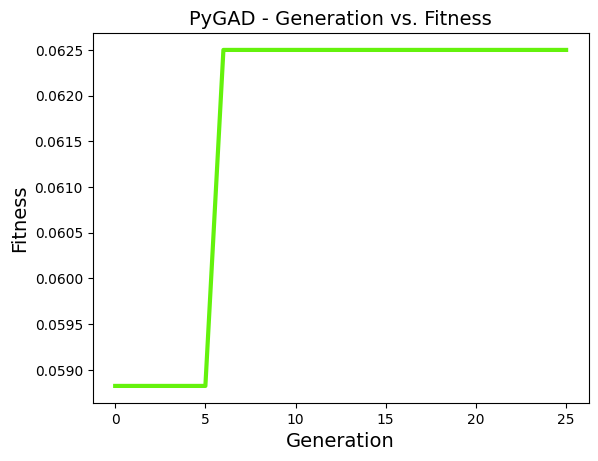

In [ ]:
ga_instance.plot_fitness();

Se combinó *sol_per_pop=50* con *random_seed=42* para garantizar
que el algoritmo encuentre el **óptimo global (16 días)** de forma
reproducible. Con poblacion más pequeña (20) sin semilla fija, el algoritmo
a veces convergía en 17 días en lugar del óptimo de 16.

La curva muestra **evolución real**: el fitness arranca en ~0.059
(17 días) y sube alrededor de la generación 5 hasta converger
en ~0.0625 (16 días), donde se estabiliza. Esto confirma que
el algoritmo necesitó evolucionar para encontrar el **orden óptimo**.


**Análisis de Resultados**

El algoritmo encontró el orden óptimo de tareas en pocas generaciones, reduciendo el día final de obra de 17 a 16 días respetando siempre el límite de 10 operarios por día. La curva converge rápidamente porque el espacio de soluciones es relativamente pequeño (10 tareas).


In [ ]:
solution, solution_fitness, _ = ga_instance.best_solution()
orden_optimo = np.argsort(solution)
print(f"Orden óptimo: {orden_optimo}")
print(f"Día final: {round(1/solution_fitness)}")

nombres = ["Cimientos","Muros","Techo","Instalaciones","Revoque","Pisos","Pintura","Aberturas","Electricidad","Final de obra"]
print("Orden de ejecución:")
for i, tarea_id in enumerate(orden_optimo):
    print(f"  {i+1}. {nombres[tarea_id]}")

Orden óptimo: [2 8 3 6 9 5 0 7 1 4]
Día final: 16
Orden de ejecución:
  1. Techo
  2. Electricidad
  3. Instalaciones
  4. Pintura
  5. Final de obra
  6. Pisos
  7. Cimientos
  8. Aberturas
  9. Muros
  10. Revoque
